# Plot average traces

- function for that were previously defined in corresponding workflow notebook ([link](workflow_plot_traces.ipynb))

In [2]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

# Create access to djimaging database

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-10-30 15:56:53,589][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-10-30 15:56:53,647][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Define Key

## Experimental date

In [13]:
# Define date
date = datetime.date(2025, 10, 23)
date_savepath = date.strftime("%Y%m%d")

print(date)
print(date_savepath)

2025-10-23
20251023


## Field

In [14]:
# Check possible fields
experimental_fields = (
    dj.U('field') & (Presentation() & {"date": date})
).fetch('field')

print(experimental_fields)

['XY7' 'XY8' 'XY1' 'XY2' 'XY3' 'XY4' 'XY5' 'XY6']


In [15]:
# Select a field
picked_field = "XY3"
picked_field

'XY3'

## Treatment

In [16]:
# Check possible fields
conditions = (
    dj.U('cond2') & (Presentation() & {"date": date, "field": picked_field})
).fetch('cond2')

print(conditions)

['C1' 'C2']


## Stimulus

In [17]:
# Check possible fields
stimuli = (
    dj.U('stim_name') & (Presentation() & {"date": date})
).fetch('stim_name')

print(stimuli)

['gChirp' 'lChirp' 'movingbar']


## ROI ID

### ChirpQI

In [18]:
ChirpQI() & {"date": date, "field": picked_field, "stim_name": "gChirp", "cond2": "C1"} & "qidx > 0.3"

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,2,1,0.374023,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,3,1,0.337556,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,12,1,0.328745,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,15,1,0.31041,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,23,1,0.389332,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,25,1,0.34175,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,26,1,0.333061,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,29,1,0.349752,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,33,1,0.374039,0.2
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,35,1,0.319518,0.2


In [19]:
(ChirpQI() & {"date": date, "field": picked_field, "cond2": conditions[0], "stim_name": "gChirp"} & "qidx > 0.3").fetch("roi_id")

array([  2,   3,  12,  15,  23,  25,  26,  29,  33,  35,  36,  38,  42,
        46,  48,  49,  55,  60,  64,  65,  74,  75,  76,  78,  80,  81,
        83,  85,  86,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 102, 104, 105, 106, 107, 109, 110, 111, 113])

In [20]:
# Filter for all ROIs which have a ChirpQI > 0.3 in DETA/NO and C1
# Define ROIs in C1 with ChirpQI > 0.3
# Asumed that if ROI in C1 and DETANO w/ ChirpQI > 0.3 --> ChirpQI C2 > 0.3
roi_a_chirp = set((ChirpQI() & {
    "cond2": conditions[0],
    "date": date, 
    "field": picked_field,
    "stim_name": stimuli[0]} & "qidx > 0.3").fetch("roi_id"))

# Define ROIs in DETA/NO with ChirpQI > 0.3
roi_b_chirp = set((ChirpQI() & {
    "cond2": conditions[1], 
    "date": date, 
    "field": picked_field,
    "stim_name": stimuli[0]} & "qidx > 0.3").fetch("roi_id"))

# Define ROIs in both conditions
common_rois_chirp = list(roi_a_chirp & roi_b_chirp)

# Check output
print("Number of ROIs(QIChirp>0.3) in both treatments: ", len(common_rois_chirp))
for i in common_rois_chirp:
    print(i)

Number of ROIs(QIChirp>0.3) in both treatments:  43
2
3
12
15
23
29
33
35
36
38
42
46
48
49
60
65
75
76
78
83
86
89
90
91
92
93
94
95
96
97
98
99
100
101
102
104
105
106
107
109
110
111
113


In [21]:
# Pick ROI from list above
picked_roi = 15
picked_roi

15

## Retina location

In [22]:
# Define the retina (e.g., LR or RR)
retina = (
    dj.U('region') & 
    (Snippets() & {
        "date": date, 
        "field": picked_field, 
        "roi_id": picked_roi, 
        "stim_name": "gChirp"})).fetch('region')

retina = str(retina[0])
print(retina)

RR


In [23]:
# Fetsch region (e.g., d, v, n, or t)
region = (
    dj.U('cond1') & 
    (Snippets() & {
        "date": date, 
        "field": picked_field, 
        "roi_id": picked_roi, 
        "stim_name": "gChirp"})).fetch('cond1')

region = str(region[0])
print(region)

n


## Define key

In [24]:
# Key
key = {
    "date": date,
    "field": picked_field,
    "cond2": conditions[0],
    "stim_name": stimuli[0],
    "roi_id": picked_roi
}
key

{'date': datetime.date(2025, 10, 23),
 'field': 'XY3',
 'cond2': 'C1',
 'stim_name': 'gChirp',
 'roi_id': 15}

# Plot the field with the ROI

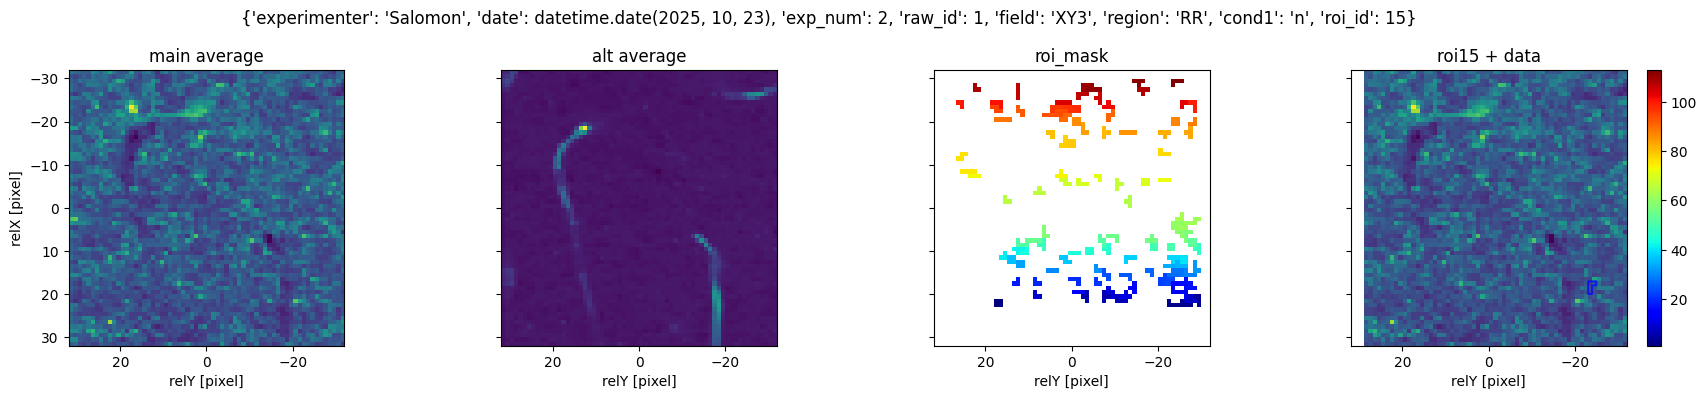

In [35]:
# Plot ROI
(Roi() & key).plot1()
plt.savefig(f"plots/20251023/gchirp/M1_{retina}_{region}_{picked_field}_gChirp_ROI{picked_roi}_image.png",
           dpi=300,
           bbox_inches="tight")

In [29]:
# Check if entry exists in database
Snippets() & key

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,snippets array of snippets (time x repetitions),"snippets_t0 array of snippet start times (repetitions, )",snippets_dt,triggertimes_snippets snippeted triggertimes (ntrigger_rep x repetitions),droppedlastrep_flag Was the last repetition incomplete and therefore dropped?
Salomon,2025-10-23,2,1,XY3,RR,n,gChirp,C1,15,1,=BLOB=,=BLOB=,0.128,=BLOB=,0


# Plot Chirp Trace

- function defined previously

In [30]:
def plot_snippets_and_average(
    key=None,
    ylim=None,
    axs=None,
    colors=["#794b5d", "#be305d"]):

    """
    Plot signal snippets and their average, aligned relative to a trigger time.

    This function retrieves time-aligned signal snippets and their corresponding 
    averages from a DataJoint database, then plots:
        1. All individual snippets (in grey, semi-transparent)
        2. The mean trace of all snippets
        3. Vertical dashed lines indicating relative trigger times

    Parameters
    ----------
    key : dict, optional
        A DataJoint restriction key used to fetch the specific dataset 
        from the `Snippets` and `Averages` tables.
    colors : list of str, optional
        A list of two hex color strings:
            colors[0] - color for the average trace
            colors[1] - color for vertical trigger lines
        Defaults to cyan (`#00ccffff`) and yellow (`#ffcc00ff`).

    Notes
    -----
    - Relies on DataJoint tables `Snippets` and `Averages`.
    - Uses an external function `get_aligned_snippets_times()` for time alignment.
    - Assumes `snippets` is shaped (time_points, num_snippets).
    """

    # --- Fetsch snippet data from the Snippets table ---
    # snippets_t0: start times for each snippet
    # snippets_dt: time step between samples
    # snippets: 2D array of signal snippets
    # triggertimes_snippets: trigger times associated with each snippet
    snippets_t0, snippets_dt, snippets, triggertimes_snippets = (
        Snippets() & key
    ).fetch1("snippets_t0", "snippets_dt", "snippets", "triggertimes_snippets")

    # Create a 2D array of time values for each snippet
    # Shape: (time_points, num_snippets)
    snippets_times = (
        np.tile(np.arange(snippets.shape[0]) * snippets_dt, (len(snippets_t0), 1)).T
        + snippets_t0
    )

    # --- Set up the plot ---
    if axs is None:
        fig, axs = plt.subplots(1, 1, figsize=(10, 2))

    # Plot all snippets relative to the first trigger time
    axs.plot(
        snippets_times - triggertimes_snippets[0],
        snippets,
        alpha=0.25,
        color="grey"
    )
    axs.set(ylabel='trace', xlabel='rel. to trigger', xlim=None)
    axs.set_ylim(ylim)

    # --- Fetch average trace data from the Averages table ---
    # triggertimes_rel = (
    #     Averages() & key
    # ).fetch1('triggertimes_rel')

    # Plot the mean trace of all snippets
    axs.plot(
        snippets_times - triggertimes_snippets[0],
        np.mean(snippets, axis=1),
        color=colors[0]
    )

    axs.axvline(
        x=0,
        color=colors[1],
        linestyle="--",
        linewidth=2)
    
    #triggertimes_rel = triggertimes_rel[0]

    # Mark relative trigger times with dashed vertical lines
    #for x in triggertimes_rel:
    #    axs.axvline(
    #        x=x,
    #        color=colors[1],
    #        linestyle='--',
    #        linewidth=2
    #    )

In [31]:
triggertimes_rel = (
        Averages() & key
    ).fetch1('triggertimes_rel')
triggertimes_rel[0]

np.float32(0.0)

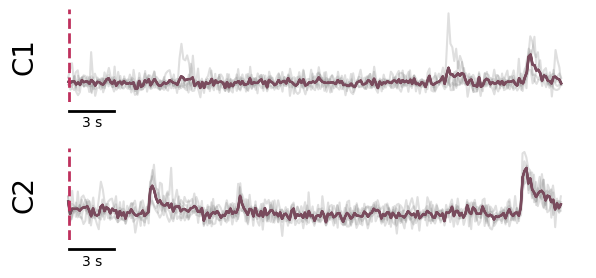

In [34]:
key["stim_name"] = stimuli[0]

fig, axs = plt.subplots(2, 1, figsize=(7,3), sharex=True)

plt.subplots_adjust(hspace=0.5)

for i, condition in enumerate(conditions):

    key["cond2"] = condition
    chirp_qi = np.round((ChirpQI() & key).fetch1("qidx"), 2)
    
    plot_snippets_and_average(key=key, axs=axs[i], colors=["#794b5d", "#be305d"])
    
    #if i == 0:
    #    axs[i].set_title(f"Date: {date}, Field: {picked_field}, ROI ID: {picked_roi}, Treatment: {condition}, Chirp QI: {chirp_qi}", fontsize=10)

    #else:
    #    axs[i].set_title(f"Treatment: {condition}, Chirp QI: {chirp_qi}", fontsize=10)

    #if i < len(axs) - 1:
    #    axs[i].set_xlabel("")

    # After plotting inside your loop
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    
    # Remove ticks and labels
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlabel("")
    axs[i].set_ylabel(condition, fontsize=20)
    
    # Example: add a scale bar of 5 seconds (adjust as needed)
    scalebar_len = 3  # seconds
    x_start = 0       # where the bar starts on the x-axis
    y_pos = -0.1     # relative position (in axis coords)
    
    # Draw horizontal bar
    axs[i].plot([x_start, x_start + scalebar_len],
                [y_pos, y_pos], color="black", lw=2, clip_on=False,
                transform=axs[i].get_xaxis_transform())
    
    # Annotate it
    axs[i].text(x_start + scalebar_len/2, y_pos - 0.05,
                f"{scalebar_len} s", ha="center", va="top",
                transform=axs[i].get_xaxis_transform())

plt.savefig(f"plots/{date_savepath}/gchirp/M1_{retina}_{region}_{picked_field}_{stimuli[0]}_ROI{picked_roi}_trace.png",
           dpi=300,
           bbox_inches="tight")

# Plot delta of the chirp trace
- based on the average

In [26]:
def plot_trace_and_snippets(
    key=None,
    ylim=None,
    axs=None,
    colors=["#00ccffff", "#ffcc00ff"]):

    snippets_t0, snippets_dt, snippets, triggertimes_snippets = (Snippets() & key).fetch1(
                "snippets_t0", "snippets_dt", "snippets", "triggertimes_snippets")

    snippets_times = (np.tile(np.arange(snippets.shape[0]) * snippets_dt, (len(snippets_t0), 1)).T
                          + snippets_t0)

    snippets_times_norm = snippets_times - snippets_times[0][0]

    triggertimes_snippets_norm = triggertimes_snippets - triggertimes_snippets[0][0]
    
    if axs is None:
        fig, axs = plt.subplots(1, 1, figsize=(10, 2))

    axs.plot(snippets_times_norm, snippets, color=colors[0])

    if len(triggertimes_snippets) > 0:
        axs.vlines(triggertimes_snippets_norm, np.min(snippets), np.max(snippets), color=colors[1], label='trigger', zorder=-2)

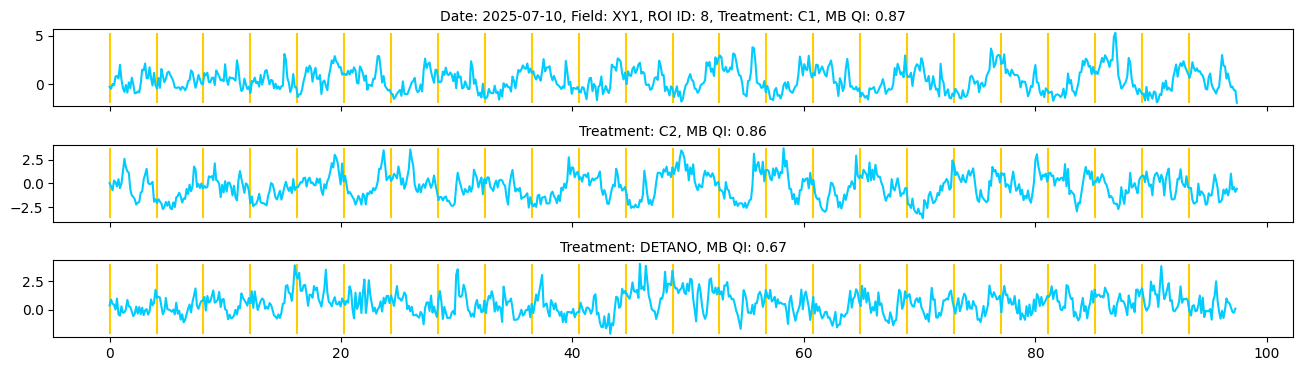

In [27]:
key["stim_name"] = stimuli[1]

fig, axs = plt.subplots(3, 1, figsize=(16,4), sharex=True)

plt.subplots_adjust(hspace=0.5)

for i, condition in enumerate(conditions):

    key["cond2"] = condition
    mb_qi = np.round((OsDsIndexes() & key).fetch1("d_qi"), 2)
    
    plot_trace_and_snippets(key=key, axs=axs[i])
    
    if i == 0:
        axs[i].set_title(f"Date: {date}, Field: {picked_field}, ROI ID: {picked_roi}, Treatment: {condition}, MB QI: {mb_qi}", fontsize=10)

    else:
        axs[i].set_title(f"Treatment: {condition}, MB QI: {mb_qi}", fontsize=10)

    if i < len(axs) - 1:
        axs[i].set_xlabel("")

plt.savefig(f"plots/20250710/mb/M1_{retina}_{region}_{picked_field}_{stimuli[1]}_ROI{picked_roi}.png",
            dpi=600,
            bbox_inches="tight")